# Thermogenic lipolysis in brown adipocytes

Immortalised murine brown adipocytes, stimulated with norepinephrine to
trigger the non-shivering cold response. Six replicates per timepoint;
transcriptome and proteome at 0, 4 and 24 h; metabolome at seven points
between 0 and 24 h.

The data and the published analysis are
[Anagho-Mattanovich *et al.*, *iScience* 28(9):113382, 2025](https://doi.org/10.1016/j.isci.2025.113382),
which compared five ways of integrating them. This notebook runs the
trans-omic network reading and ends by setting it beside what that paper
concluded.

Needs the mouse network: `python maintenance/build_networks.py --organisms
mouse --brenda`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from transnet import (
    build_name_id_map,
    assign_temporal_parameters,
    compare_transomic_networks,
    cross_layer_connectivity,
    downstream_influence,
    temporal_network_structure,
    expression_concordance,
    layer_coverage,
    map_omics_to_network,
    metabolite_regulatory_roles,
    path_consistency_summary,
    reaction_regulation_table,
    regulation_axis_summary,
    regulatory_role_enrichment,
    responsive_subnetwork,
    trace_regulatory_paths,
    transcription_factor_activity,
    transomic_hubs,
)
from transnet.analysis.factors import (
    matched_transcript_protein,
    pairing_robustness,
    sample_pairing_check,
    factor_cross_layer_agreement,
    factor_design_association,
    factor_network_propagation,
    factor_network_coherence,
    factor_variance_explained,
    fit_factors,
)
from transnet.analysis import (
    cluster_temporal_trajectories,
    compute_timecourse_statistics,
    id_mapping,
    path_verdicts,
    versus_chance,
)
from transnet.datasets import (
    BROWN_ADIPOCYTE_HOURS,
    DATA_DIR,
    brown_adipocyte_contrast,
    load_brown_adipocyte_omics,
    timepoint_columns,
)
from transnet.io import read_network

OUT = DATA_DIR / "brown_adipocyte_results"
OUT.mkdir(parents=True, exist_ok=True)

omics = load_brown_adipocyte_omics()
pd.DataFrame({layer: {"features": frame.shape[0], "samples": frame.shape[1]}
              for layer, frame in omics.items()}).T

,features,samples
Transcriptome,13182,18
Proteome,3321,18
Metabolome,171,42


## The network

The organism-wide mouse network: KEGG reactions, UniProt proteins, STRING
interactions, ChIP-Atlas binding and BRENDA allosteric effectors.

In [2]:
source = DATA_DIR / "mouse" / "latest"
graph = read_network(str(source / "interactions.csv"), nodes_file=str(source / "nodes.csv"))
print(f"{graph.number_of_nodes():,} molecules, {graph.number_of_edges():,} relationships")

106,859 molecules, 1,938,789 relationships


## How much of this network crosses layers

A network whose edges sit inside single layers is a stack of separate
single-omics networks; this fraction is what earns the name.

In [3]:
connectivity = cross_layer_connectivity(graph)
print(f"{connectivity['cross_layer_fraction']:.0%} of edges cross between layers")
connectivity["matrix"]

82% of edges cross between layers


,Transcriptome,Proteome,Reactions,Metabolome
Transcriptome,0,17126,0,0
Proteome,1496009,355312,32899,0
Reactions,0,0,0,8133
Metabolome,0,0,29310,0


## Identifiers

Transcripts are Ensembl, the network's genes are Entrez; metabolites are
names, the network's are KEGG compounds. Both maps are built once.

In [4]:
idmap_file = OUT / "ensembl_to_entrez.json"
if idmap_file.exists():
    gene_map = pd.read_json(idmap_file, typ="series").astype(str).to_dict()
else:
    mapped = id_mapping(
        pd.DataFrame({"feature": omics["Transcriptome"].index}),
        id_col="feature", from_type="ensembl.gene", to_type="entrezgene",
        organism="mouse",
    ).dropna(subset=["entrezgene_id"])
    gene_map = dict(zip(mapped["feature"].astype(str),
                        mapped["entrezgene_id"].astype(str)))
    pd.Series(gene_map).to_json(idmap_file)

metabolite_map = build_name_id_map(graph, list(omics["Metabolome"].index))
id_map = {"Transcriptome": gene_map, "Metabolome": metabolite_map}
print(f"{len(gene_map):,} transcripts and {len(metabolite_map)} metabolites resolved")

12,012 transcripts and 119 metabolites resolved


## The contrast

24 h of sustained stimulation against unstimulated cells. Every layer is
log2, so a fold change is a difference of means; the standard error comes
with it, which is what lets a protein's change be compared with its
transcript's without a threshold (transcript-protein concordance).

In [5]:
CONTROL, TREATMENT = "0h", "24h"
tables = {layer: brown_adipocyte_contrast(frame, CONTROL, TREATMENT)
          for layer, frame in omics.items()}

report = map_omics_to_network(
    graph, tables, id_column="feature", log2fc_column="log2FC",
    qvalue_column="padj", se_column="se", id_map=id_map, qvalue_threshold=0.05,
)
report.per_layer

,layer,n_supplied,n_matched,match_fraction,n_layer_nodes,layer_covered,n_up,n_down,n_undirected,note
0,Transcriptome,13182,13006,0.986648,57540,0.225965,3469,3414,0,
1,Proteome,3321,1649,0.496537,17283,0.095412,214,248,0,
2,Metabolome,171,119,0.695906,19652,0.006004,3,36,0,


In [6]:
coverage = layer_coverage(graph)
coverage

,layer,n_nodes,n_measured,measured_fraction,n_responsive,n_regulated,n_up,n_down,mean_degree
0,Transcriptome,57540,13002,0.225965,6882,6882,3468,3414,26.297098
1,Proteome,17283,1649,0.095412,462,462,214,248,130.570966
2,Reactions,12384,0,0.000000,0,0,0,0,5.680071
3,Metabolome,19652,118,0.006004,38,38,3,35,1.905302


The metabolome covers a small fraction of the network's compounds, and that
limit runs through everything below: a reaction is judged on the metabolites
that were measured, not on the ones that exist.

## Where the layers converge

In [7]:
responsive = responsive_subnetwork(graph)
print(f"{responsive.number_of_nodes():,} responsive molecules, "
      f"{responsive.number_of_edges():,} relationships between them")

6,568 responsive molecules, 21,383 relationships between them


## Which axis regulates each reaction

In [8]:
regulation = reaction_regulation_table(graph)
regulated = regulation[(regulation["gene_axis"] != 0) | (regulation["metabolite_axis"] != 0)]
enzyme_only = regulated[(regulated["gene_axis"] != 0) & (regulated["metabolite_axis"] == 0)]
metabolite_only = regulated[(regulated["gene_axis"] == 0) & (regulated["metabolite_axis"] != 0)]
both = regulated[(regulated["gene_axis"] != 0) & (regulated["metabolite_axis"] != 0)]
controversial = regulated[regulated["controversial"]]

print(f"{len(regulated):,} reactions regulated: {len(enzyme_only):,} through enzyme amount "
      f"only, {len(metabolite_only):,} through metabolites only, {len(both):,} through both")
print(f"{len(controversial):,} are controversial -- the two axes point opposite ways")
regulation.to_csv(OUT / "reaction_regulation.csv", index=False)
controversial.head(10)[["reaction", "name", "gene_axis", "metabolite_axis",
                        "allosteric_regulators"]]

2,393 reactions regulated: 1,902 through enzyme amount only, 229 through metabolites only, 262 through both
154 are controversial -- the two axes point opposite ways


,reaction,name,gene_axis,metabolite_axis,allosteric_regulators
143,R00177,ATP:L-methionine S-adenosyltransferase; Orthop...,-1,1,
180,R00219,2-hydroxyethylenedicarboxylate carboxy-lyase (...,1,-1,
181,R00220,L-serine ammonia-lyase; L-Serine <=> Pyruvate ...,-1,1,C00049(activated)
193,R00237,(3S)-citramalyl-CoA pyruvate-lyase (acetyl-CoA...,-1,1,
197,R00245,L-glutamate gamma-semialdehyde:NAD+ oxidoreduc...,-1,1,C00042(activated)
198,R00248,L-glutamate:NADP+ oxidoreductase (deaminating)...,-1,1,
201,R00253,L-glutamate:ammonia ligase (ADP-forming); ATP ...,-1,1,
208,R00261,L-glutamate 1-carboxy-lyase (4-aminobutanoate-...,-1,1,C00026(activated);C00049(activated);C00149(act...
211,R00264,"2,5-dioxopentanoate:NADP+ 5-oxidoreductase; 2,...",-1,1,
291,R00355,L-aspartate:2-oxoglutarate aminotransferase; L...,-1,1,C00064(activated);C00123(activated);C00073(act...


## Per-pathway balance

The same attribution, aggregated: which pathways are driven by enzyme
amount, which by their metabolites, and where the two disagree.

In [9]:
pathway_balance = regulation_axis_summary(regulation)
pathway_balance.head(12)

,pathway,n_reactions,gene_activated,gene_inhibited,metabolite_activated,metabolite_inhibited,n_controversial,fraction_controversial,fraction_gene_driven,fraction_metabolite_driven
0,all,2393,487,1677,225,266,154,0.064354,0.904304,0.205182


## Is each protein change transcriptional?

The paper's own example of transcript-protein divergence is the lipid
droplet machinery: *Sqle* and *Fdft1* transcripts fall at 4 h while their
proteins rise. That is exactly the `discordant` category here.

In [10]:
concordance = expression_concordance(graph)
counts = concordance["counts"]
print(f"{counts['concordant']} concordant, {counts['protein_only']} protein-only, "
      f"{counts['transcript_only']} transcript-only, {counts['discordant']} against "
      f"their transcript")
print(f"{counts.get('protein_beyond_transcript')} proteins moved significantly further "
      f"than their transcript (of {counts.get('tested_difference')} testable)")
concordance["table"].to_csv(OUT / "concordance.csv", index=False)

named = concordance["table"].assign(
    symbol=lambda d: [graph.nodes[p].get("symbol") or graph.nodes[p].get("name")
                      for p in d["protein"]])
PAPER_GENES = ["Sqle", "Fdft1", "Pnpla2", "Plin2", "Pdk4", "Ucp1"]
columns = [c for c in ("symbol", "gene_log2fc", "protein_log2fc", "category",
                       "difference", "difference_q", "protein_beyond_transcript")
           if c in named.columns]
named[named["symbol"].isin(PAPER_GENES)][columns]

165 concordant, 170 protein-only, 746 transcript-only, 126 against their transcript
292 proteins moved significantly further than their transcript (of 1661 testable)


,symbol,gene_log2fc,protein_log2fc,category,difference,difference_q,protein_beyond_transcript
498,Ucp1,-2.585472,0.457092,transcript_only,3.042564,2.458985e-45,False
806,Sqle,-0.404040,-0.844500,transcript_only,-0.440460,4.026311e-01,False
1154,Pdk4,-0.255825,2.258577,discordant,2.514402,5.807653e-20,True


## Which factors drive the responsive genes?

In [11]:
factors = transcription_factor_activity(graph, min_targets=5)
implicated = factors[factors["q_value"] <= 0.05]
print(f"{len(implicated)} of {len(factors)} transcription factors implicated")
implicated.head(10)[["name", "n_responsive_targets", "n_up", "n_down", "q_value",
                     "inferred_activity", "factor_regulated"]]

225 of 703 transcription factors implicated


,name,n_responsive_targets,n_up,n_down,q_value,inferred_activity,factor_regulated
0,Dr1,5799,2912,2887,4.826710e-30,0,NaN
1,Tle3,2526,1189,1337,3.602932e-22,-1,NaN
2,Utf1,5655,2819,2836,6.424822e-21,0,NaN
3,Tfap2c,5130,2533,2597,4.595851e-19,0,NaN
4,Sap130,5500,2749,2751,9.440324e-16,0,NaN
5,Rec8,4480,2273,2207,1.926939e-15,0,NaN
6,Tead1,2919,1476,1443,1.183103e-14,0,NaN
7,Ino80,4257,2162,2095,1.183103e-14,0,NaN
8,Klf3,3709,1865,1844,3.895997e-14,0,NaN
9,Taf2,5378,2684,2694,4.173082e-14,0,NaN


## Do the changed metabolites regulate anything?

In [12]:
roles = regulatory_role_enrichment(metabolite_regulatory_roles(graph))
row = roles["enrichment"].set_index("role").loc["any"]
counts = roles["counts"]
print(f"{counts['n_differential_regulators']} of {counts['n_differential']} changed "
      f"metabolites act on an enzyme ({counts['fraction_differential_regulators']:.0%} "
      f"against {counts['fraction_background_regulators']:.0%} of all measured; "
      f"q = {row['q_value']:.2g})")
roles["regulators"].head(10)[["name", "log2fc", "reactions_activated", "reactions_inhibited"]]

21 of 38 changed metabolites act on an enzyme (55% against 52% of all measured; q = 0.55)


,name,log2fc,reactions_activated,reactions_inhibited
0,L-Carnitine; L-gamma-Trimethyl-beta-hydroxybut...,-2.018786,R01624;R01626;R01923;R02152;R04361;R04364;R044...,
1,NAD+; NAD; Nicotinamide adenine dinucleotide; ...,-0.525167,R00635;R01489;R01709;R02125;R02657;R03871;R040...,R00762;R01130;R01383;R01845;R02358;R02389;R024...
2,L-Methionine; Methionine; L-2-Amino-4methylthi...,-0.582701,R00628;R01351;R01352;R01369;R04727;R05669;R072...,R00355;R00372;R00628;R00652;R00694;R00734;R008...
3,L-Glutamine; L-2-Aminoglutaramic acid,-1.650202,,R00355;R00372;R00652;R00694;R00734;R00895;R008...
4,L-Leucine; 2-Amino-4-methylvaleric acid; (2S)-...,-1.799414,,R00355;R00372;R00652;R00694;R00734;R00895;R008...
5,UDP-N-acetyl-alpha-D-glucosamine; UDP-N-acetyl...,-1.206311,R01383;R02358;R02389;R02478;R02502;R02902;R030...,R00768
6,Cytidine,1.804566,,R01567;R01666;R01736;R02089;R02099;R02321;R025...
7,"Citrate; Citric acid; 2-Hydroxy-1,2,3-propanet...",-1.666128,R00742,R00162;R00756;R00767;R00769;R00770;R01324;R013...
8,Pyruvate; Pyruvic acid; 2-Oxopropanoate; 2-Oxo...,-20.885544,R00056;R00086;R00515;R00615;R00881;R01054;R012...,R01904
9,2-Oxoglutarate; Oxoglutaric acid; 2-Ketoglutar...,-1.213716,R03451,R00261;R00489;R01682;R02466;R05419;R05493;R063...


## Signed paths to the metabolome

In [13]:
paths = trace_regulatory_paths(graph, target_layer="Metabolome", max_length=4, max_paths=20000)
verdicts, agree, tested = path_verdicts(paths)
print(f"{agree} of {tested} changed metabolites predicted in the right direction: "
      f"{versus_chance(agree, tested)}")
verdicts.head(10)[["target", "observed", "predicted", "agrees", "n_paths"]]

19 of 28 changed metabolites predicted in the right direction: 68%, no better than the 50% expected by chance (binomial p = 0.087)


,target,observed,predicted,agrees,n_paths
0,C00042,-1,-1,True,529
1,C00073,-1,-1,True,174
2,C00085,-1,-1,True,55
3,C00864,-1,-1,True,50
4,C00022,-1,1,False,61
5,C00294,-1,-1,True,26
6,C00214,-1,-1,True,25
7,C00026,-1,-1,True,27
8,C00164,-1,-1,True,27
9,C00624,-1,-1,True,27


The paths themselves, with what each one predicts against what was measured.
A chance-level rate is read from this figure, not just from the number: the
question is whether the misses are scattered or concentrated on a few
metabolites.

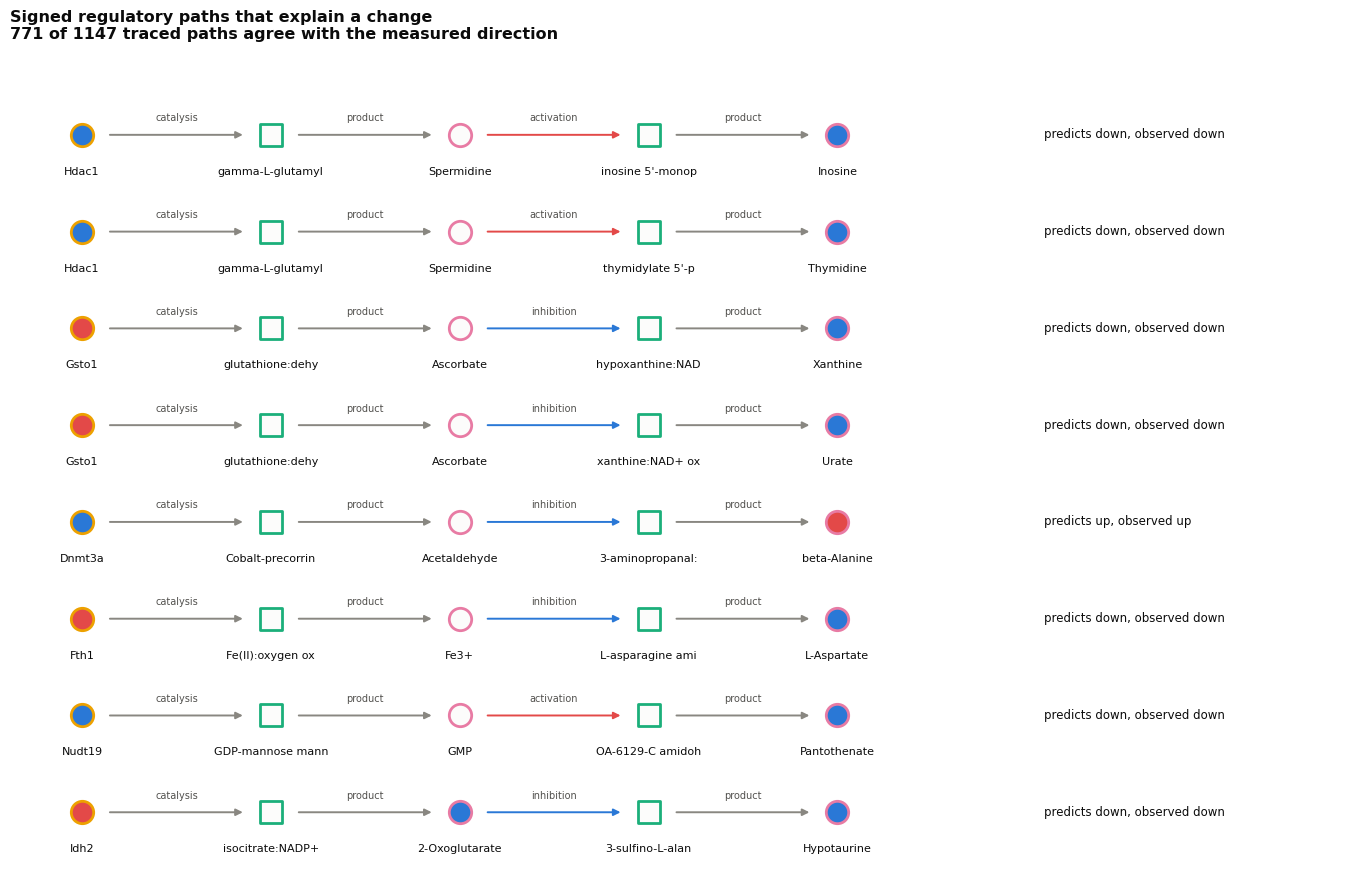

In [14]:
from transnet.visualization import plot_regulatory_paths

paths_figure = plot_regulatory_paths(paths, graph, top_n=8)
plt.show()

## Hubs across layers

In [15]:
hubs = transomic_hubs(responsive, top_percent=2)
hubs.head(10)[["name", "layer", "cross_layer_degree", "n_layers_touched"]]

,name,layer,cross_layer_degree,n_layers_touched
0,Nucleolar RNA helicase 2 (EC 3.6.4.13) (DEAD b...,Proteome,5271,2
1,Host cell factor 1 (HCF) (HCF-1) (C1 factor) [...,Proteome,3647,2
2,2-oxoglutarate dehydrogenase complex component...,Proteome,1681,3
3,Structural maintenance of chromosomes protein ...,Proteome,1719,2
4,Activity-dependent neuroprotector homeobox pro...,Proteome,1482,2
5,DNA topoisomerase 2-beta (EC 5.6.2.2) (DNA top...,Proteome,984,2
6,Metastasis-associated protein MTA2 (Metastasis...,Proteome,539,2
7,Protein dpy-30 homolog (Dpy-30-like protein) (...,Proteome,512,2
8,Parafibromin (Cell division cycle protein 73 h...,Proteome,310,2
9,Interferon regulatory factor 2-binding protein...,Proteome,576,1


## Does the upper hierarchy predict the metabolites?

Propagating the changed genes and proteins forward along signed edges gives
each metabolite a predicted direction. Comparing that with the measurement
is the strongest test the network can fail, and it usually does.

In [16]:
seeds = {n: float(d["log2fc"]) for n, d in graph.nodes(data=True)
         if d.get("layer") in ("Transcriptome", "Proteome")
         and d.get("regulated") and d.get("log2fc") is not None}
influence = downstream_influence(graph, seeds, target_layer="Metabolome")
measured = influence[influence["observed"].fillna(0) != 0] if "observed" in influence else influence
if not measured.empty and "agrees" in measured:
    agree = int(measured["agrees"].astype("boolean").fillna(False).sum())
    print(f"{agree} of {len(measured)} changed metabolites predicted correctly: "
          f"{versus_chance(agree, len(measured))}")
measured.head(10)

24 of 32 changed metabolites predicted correctly: 75%, better than the 50% expected by chance (binomial p = 0.007)


,node,layer,name,score,abs_score,predicted_direction,observed,agrees
10,C00003,Metabolome,NAD+; NAD; Nicotinamide adenine dinucleotide; ...,-0.152306,0.152306,-1,-1,True
52,C00085,Metabolome,D-Fructose 6-phosphate; D-Fructose 6-phosphori...,-0.032997,0.032997,-1,-1,True
58,C00022,Metabolome,Pyruvate; Pyruvic acid; 2-Oxopropanoate; 2-Oxo...,-0.031348,0.031348,-1,-1,True
71,C00042,Metabolome,Succinate; Succinic acid; Butanedionic acid; E...,-0.025580,0.025580,-1,-1,True
123,C00026,Metabolome,2-Oxoglutarate; Oxoglutaric acid; 2-Ketoglutar...,-0.017598,0.017598,-1,-1,True
132,C00049,Metabolome,L-Aspartate; L-Aspartic acid; 2-Aminosuccinic ...,-0.016574,0.016574,-1,-1,True
212,C00864,Metabolome,Pantothenate; Pantothenic acid; (R)-Pantothenate,0.011270,0.011270,1,-1,False
376,C00300,Metabolome,Creatine; alpha-Methylguanidino acetic acid; M...,-0.007599,0.007599,-1,-1,True
424,C03406,Metabolome,N-(L-Arginino)succinate; 2-(Nomega-L-Arginino)...,0.006923,0.006923,1,-1,False
469,C00385,Metabolome,Xanthine,-0.006118,0.006118,-1,-1,True


## Timing on the network

The seven-point metabolome gives each metabolite a half-response time. Morita
et al. ask whether the best-connected molecules respond fastest.

In [17]:
metabolome_labels = [str(c).split("_")[0] for c in omics["Metabolome"].columns]
metabolome_means = pd.DataFrame({
    timepoint: omics["Metabolome"].loc[:, [c for c, label in
                                           zip(omics["Metabolome"].columns, metabolome_labels)
                                           if label == timepoint]].mean(axis=1)
    for timepoint in dict.fromkeys(metabolome_labels)
})
# the network is keyed by KEGG compound id and the table by name; the columns
# are named for the timepoint, so rename them to the hours they stand for
hours = [BROWN_ADIPOCYTE_HOURS[label] for label in metabolome_means.columns]
timecourse = (metabolome_means.rename(index=metabolite_map)
              .set_axis(hours, axis=1).reset_index())
timecourse = timecourse.rename(columns={timecourse.columns[0]: "feature"})
timecourse = timecourse[timecourse["feature"].isin(graph.nodes)]
parameters = assign_temporal_parameters(
    graph, {"Metabolome": timecourse}, id_column="feature", time_columns=hours,
)
print(f"{parameters['t_half'].notna().sum()} metabolites have a half-response time")
structure = temporal_network_structure(graph)
print(structure["degree_vs_thalf"]["interpretation"])
structure["per_layer_thalf"]

118 metabolites have a half-response time
no association between degree and response time (p = 0.227, n = 118)


,layer,n,median_t_half,mean_t_half
0,Metabolome,118,1.565819,2.236004


## 4 h against 24 h

Two contrasts of the same cells, compared as networks: not which molecules
differ, but which *kinds* of regulation the early and late responses use.

In [18]:
early = graph.copy()
early_tables = {layer: brown_adipocyte_contrast(frame, CONTROL, "4h")
                for layer, frame in omics.items()}
map_omics_to_network(early, early_tables, id_column="feature", log2fc_column="log2FC",
                     qvalue_column="padj", se_column="se", id_map=id_map,
                     qvalue_threshold=0.05)
comparison = compare_transomic_networks(
    responsive_subnetwork(early), responsive_subnetwork(graph), "4h", "24h")
print(f"edge Jaccard between the two responses: "
      f"{comparison['summary']['edge_jaccard']:.2f}")
comparison["edges_by_type"]

edge Jaccard between the two responses: 0.20


,edge_type,n_4h,n_24h,n_shared,gained_in_24h,lost_in_24h
0,allosteric_activation,267,120,120,0,147
1,allosteric_inhibition,463,165,158,7,305
2,catalysis,1205,663,391,272,814
3,product,208,96,78,18,130
4,protein_interaction,4036,2534,598,1936,3438
5,substrate,334,151,134,17,200
6,transcriptional_regulation,7475,17363,4495,12868,2980
7,translation,341,291,98,193,243


## Factors, read through the network

The published analysis fits MOFA factors to these data. A factor model finds
co-variation; the question it cannot ask of itself is whether a factor's
strongest features are *connected*. That is what the permutation test below
answers.

In [19]:
shared_samples = sorted(
    set(omics["Transcriptome"].columns)
    & set(omics["Proteome"].columns)
    & set(omics["Metabolome"].columns)
)
matrices = {layer: frame[shared_samples].T for layer, frame in omics.items()}
design = pd.DataFrame(
    {"timepoint": [str(s).split("_")[0] for s in shared_samples]}, index=shared_samples)
print(f"{len(shared_samples)} samples measured in all three layers: "
      + ", ".join(sorted(set(design['timepoint']))))

18 samples measured in all three layers: 0h, 24h, 4h


**First, are the layers measured on the same cultures?** A joint factor model
treats `0h_01` as one sample in every layer, and so do MOFA and DIABLO. The
files share column *names*; whether they share *samples* is testable: within a
timepoint, a culture whose transcript of a gene runs high should, if it is the
same culture, tend to have that protein high too.

In [20]:
transcripts, proteins = matched_transcript_protein(
    omics["Transcriptome"], omics["Proteome"], graph, id_maps=id_map)
groups = design["timepoint"]
pairing = sample_pairing_check(transcripts, proteins, groups, n_permutations=500)
print(f"{transcripts.shape[1]:,} genes measured as transcript and protein")
print(f"agreement as listed {pairing['observed']:.3f}, under shuffled pairings "
      f"{pairing['null_mean']:.3f} (p = {pairing['p_value']:.2f}) -> "
      f"{'paired' if pairing['paired'] else 'pairing not confirmed'}")

1,656 genes measured as transcript and protein
agreement as listed 0.067, under shuffled pairings -0.001 (p = 0.00) -> paired


The pairing is confirmed: the layers are the same cultures, so the joint model
is sound, and a factor carried by culture-to-culture variation within a
timepoint is as real as one carried by the timepoints themselves. The
robustness check below still says which kind each factor is.

In [21]:
factorisation = fit_factors(matrices, n_components=5)
association = factor_design_association(factorisation.factors_, design, ["timepoint"])
variance = factor_variance_explained(factorisation)
coherence = factor_network_coherence(graph, factorisation.loadings_, id_maps=id_map,
                                     top_n=100, n_permutations=500)

(association.pivot(index="factor", columns="term", values="partial_eta_squared")
 .join(variance[variance["layer"] == "all layers"].set_index("factor")["variance_accounted"])
 .join(coherence["table"].set_index("factor")[["fold_enrichment", "q_value"]])
 .round(3))

/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


,timepoint,variance_accounted,fold_enrichment,q_value
factor,,,,
Factor1,0.518,0.221,0.497,0.998
Factor2,0.636,0.274,0.698,0.998
Factor3,0.994,0.329,2.018,0.200
Factor4,0.127,0.097,0.213,0.998
Factor5,0.751,0.271,0.739,0.998


**Every factor across the design**, and **every factor on the network**: the
top features the network actually joins, drawn with the reactions between
them.

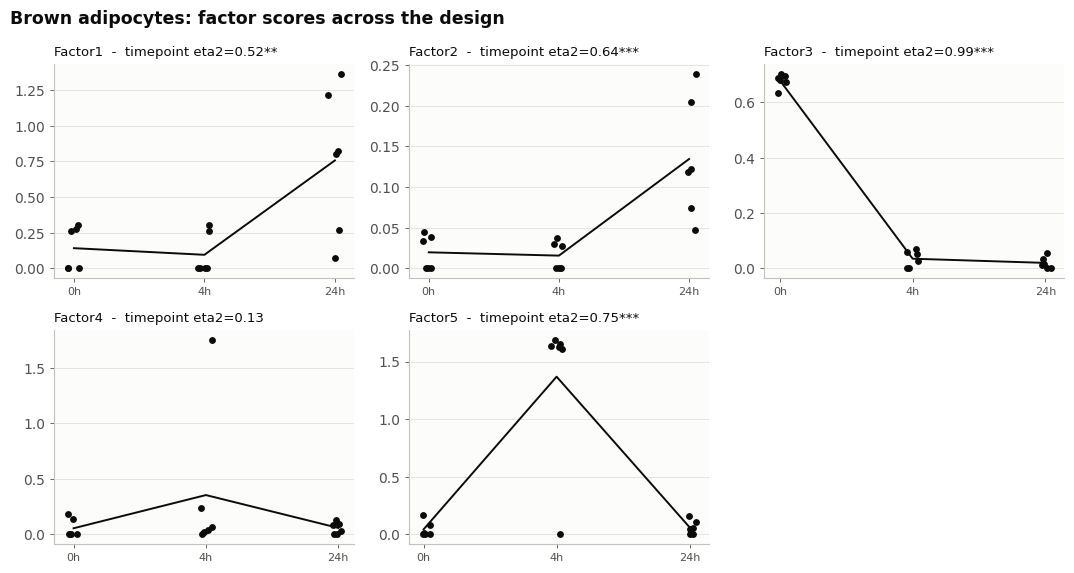

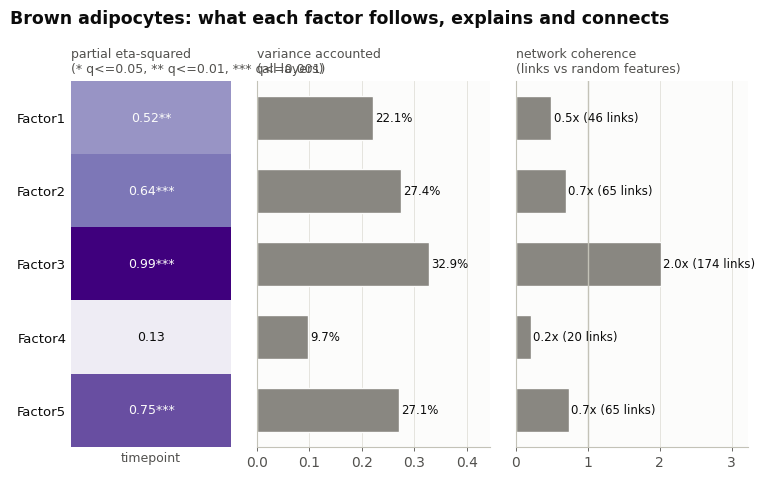

In [22]:
from transnet.visualization import plot_factor_overview, plot_factor_scores

FACTOR_OUT = OUT / "factors"
FACTOR_OUT.mkdir(parents=True, exist_ok=True)

plot_factor_scores(factorisation.factors_, design, x="timepoint",
                   x_order=["0h", "4h", "24h"], association=association,
                   title="Brown adipocytes: factor scores across the design"
                   ).savefig(FACTOR_OUT / "factor_scores.png", dpi=150, bbox_inches="tight")
plt.show()

plot_factor_overview(association, variance, coherence["table"],
                     title="Brown adipocytes: what each factor follows, explains and connects"
                     ).savefig(FACTOR_OUT / "factor_overview.png", dpi=150, bbox_inches="tight")
plt.show()

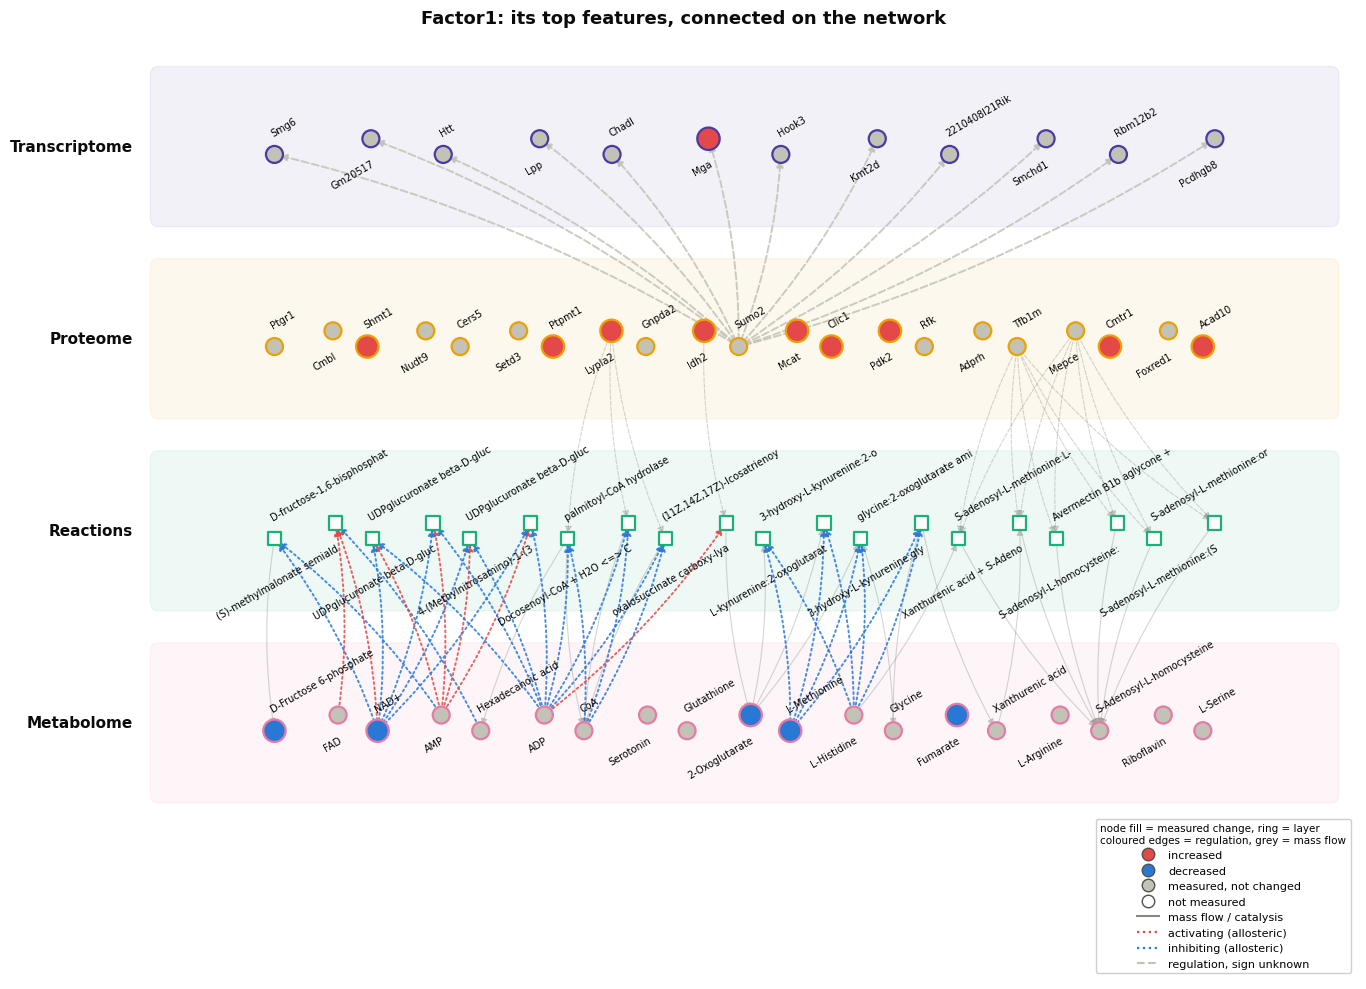

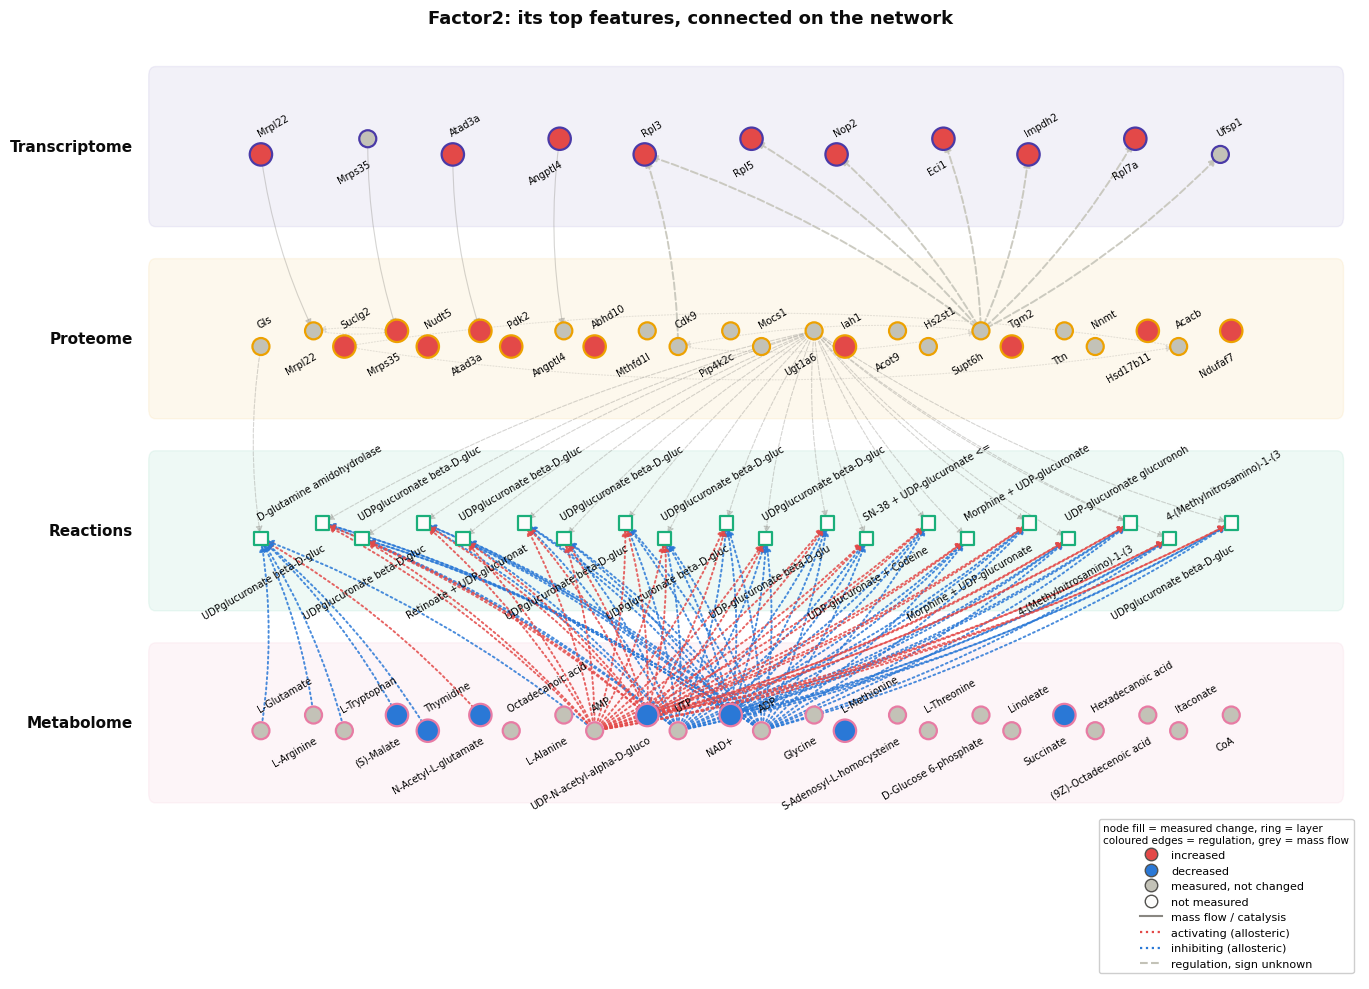

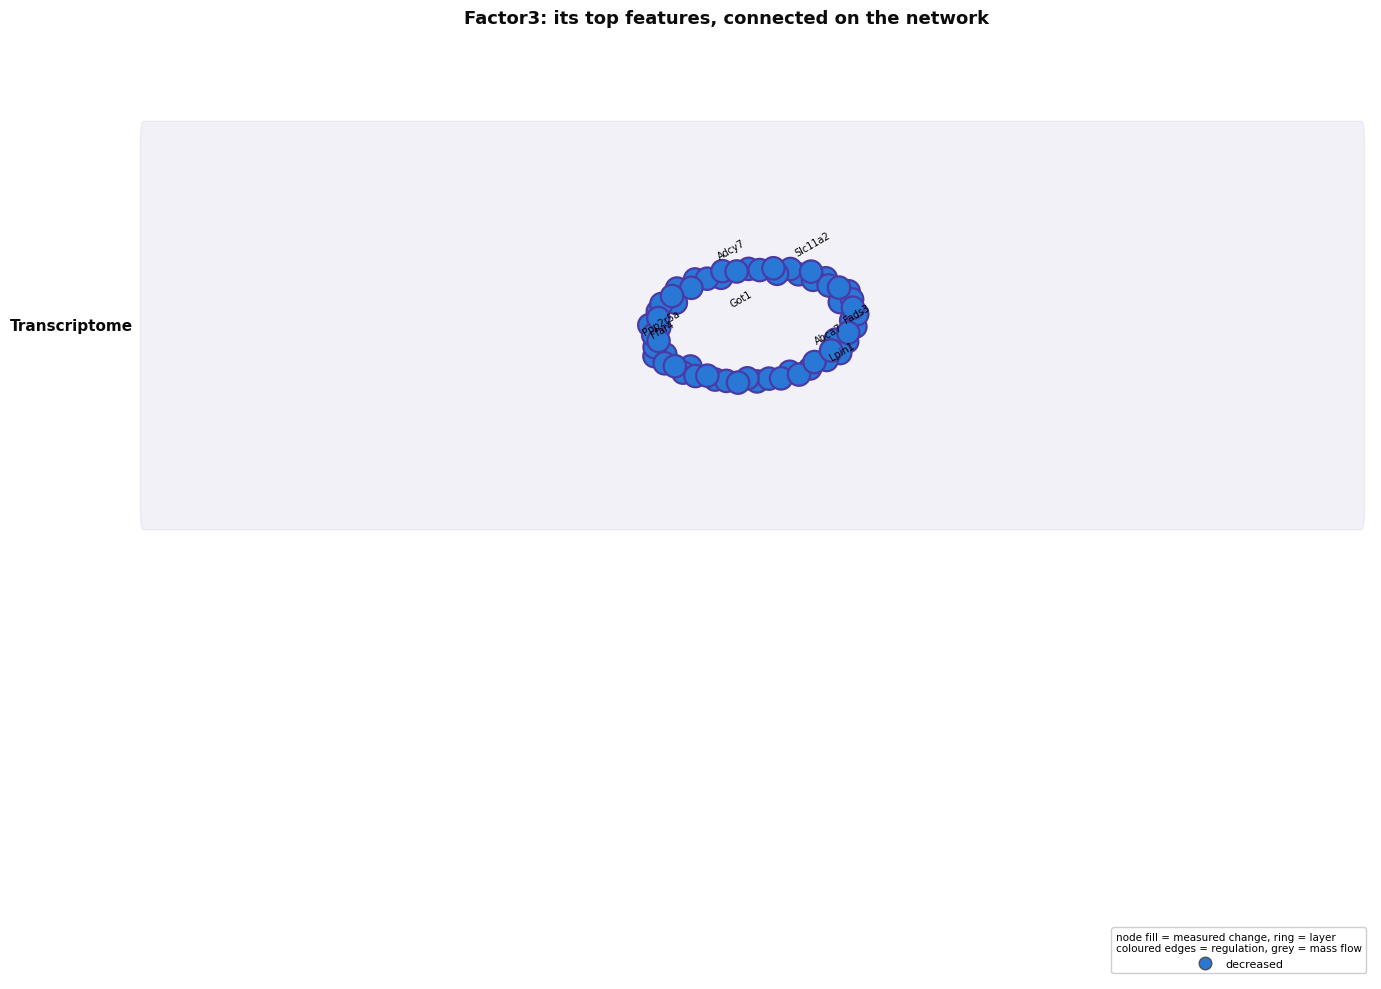

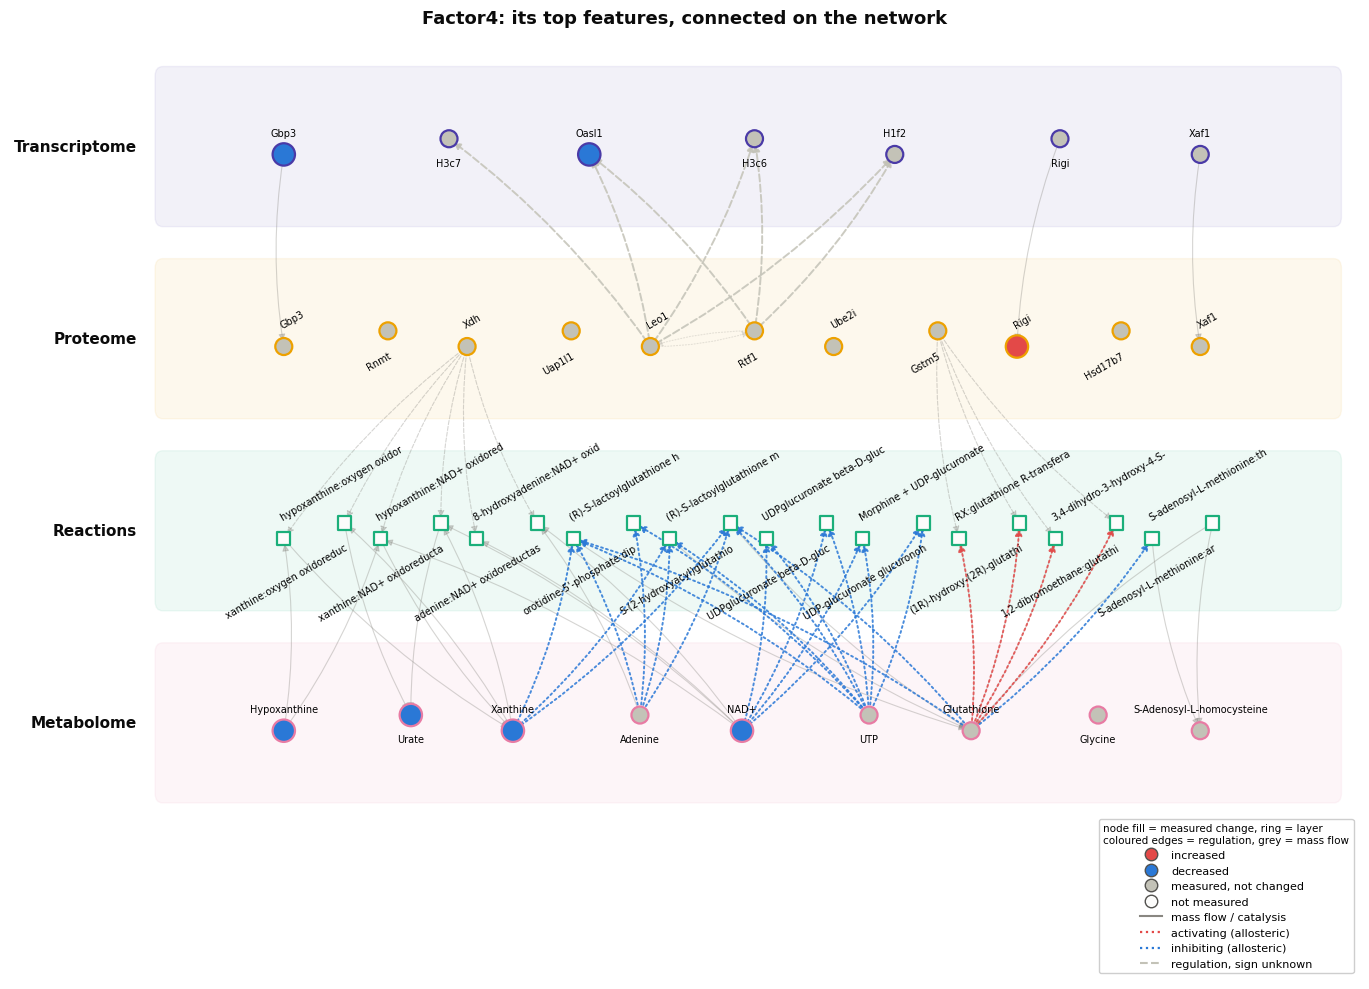

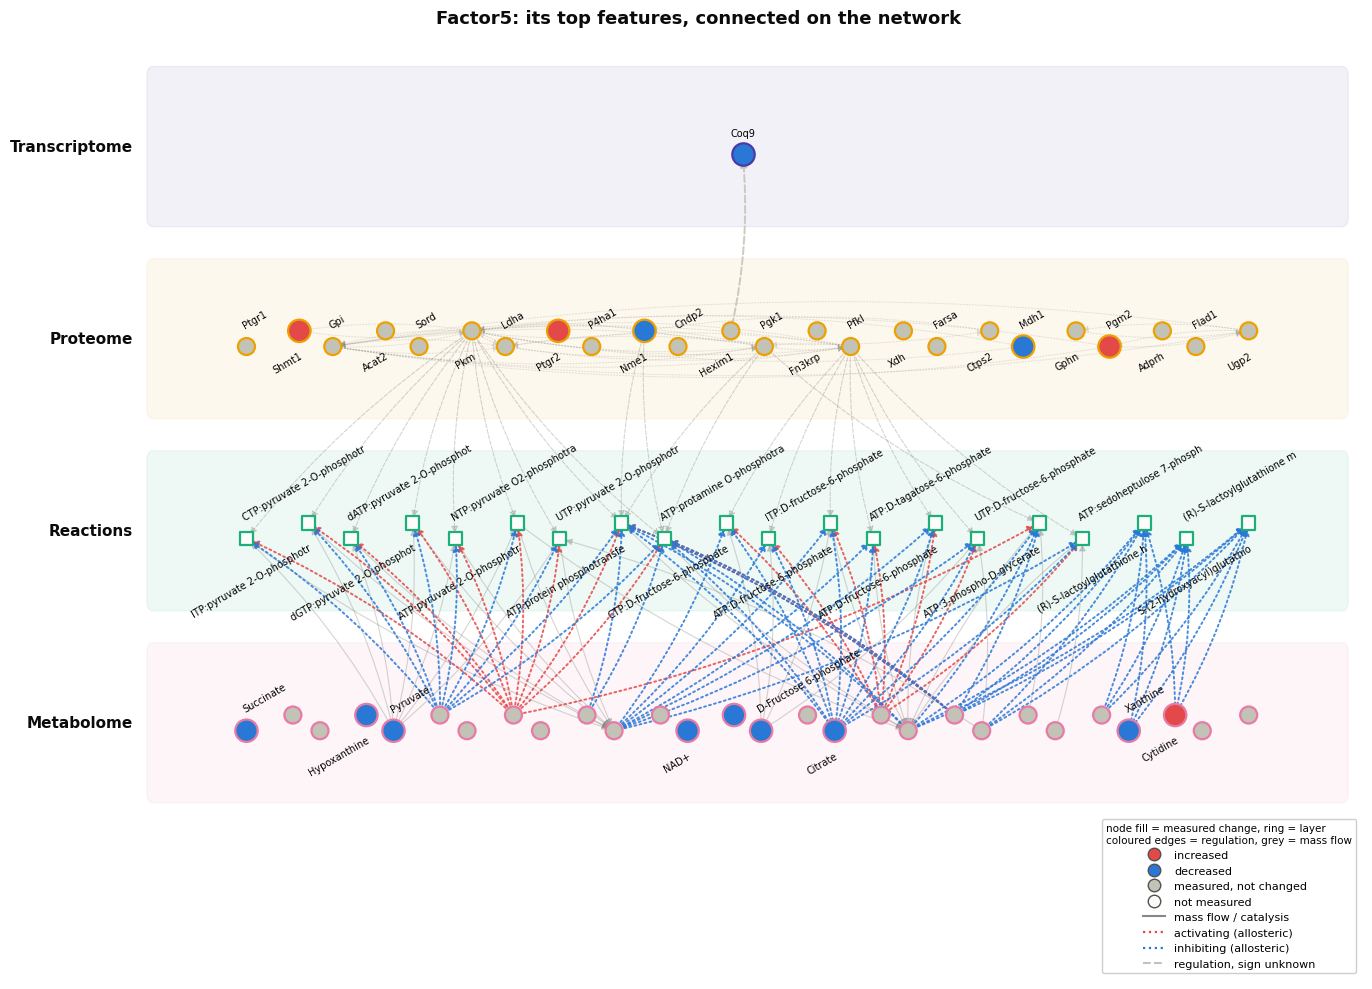

In [23]:
from transnet.visualization import plot_factor_network

for factor in factorisation.factors_.columns:
    linked = coherence["nodes"].get(factor, [])
    if not linked:
        print(f"{factor}: none of its top features are joined on the network")
        continue
    figure = plot_factor_network(graph, factorisation.loadings_, factor, id_maps=id_map,
                                 nodes=linked, max_nodes=60)
    figure.savefig(FACTOR_OUT / f"network_{factor}.png", dpi=150, bbox_inches="tight")
    plt.show()

Three further readings, each asking something of a factor that the factor
model cannot ask of itself.

**Do the layers agree?** A joint factor is fitted on the layers stacked
together, which does not make it trans-omic: one layer can carry it alone.
Projecting the samples onto a factor within each layer and correlating those
projections says which it is.

In [24]:
agreement = factor_cross_layer_agreement(factorisation)
agreement.pivot_table(index="factor", columns=["layer_a", "layer_b"],
                      values="correlation").round(2)

layer_a Metabolome                    Proteome
layer_b   Proteome Transcriptome Transcriptome
factor                                        
Factor1      -0.20          0.22          0.60
Factor2      -0.03          0.14          0.58
Factor3       0.51          0.50          0.72
Factor4      -0.08         -0.44          0.62
Factor5       0.26          0.48          0.69

**Do a factor's layers land in the same place on the network?** A joint
factor loads on transcripts, proteins and metabolites at once; that makes it
trans-omic only if those features are related by the biochemistry. Each
layer's strongest features are diffused separately, and the overlap of the
resulting profiles is compared with random features *of the same layers* --
the transcriptome is a hundred times the size of the metabolome, so a null
that ignored that would be all transcripts.

In [25]:
propagation = factor_network_propagation(graph, factorisation.loadings_,
                                         id_maps=id_map, top_n=50, n_permutations=100)
propagation["table"].round(3)

,factor,seeds_Metabolome,seeds_Proteome,seeds_Transcriptome,overlap,null_overlap,p_value,q_value
0,Factor1,33,24,49,0.060,0.055,0.347,0.347
1,Factor2,29,29,50,0.147,0.062,0.010,0.012
2,Factor3,34,23,50,0.139,0.054,0.010,0.012
3,Factor4,33,22,50,0.119,0.052,0.010,0.012
4,Factor5,28,19,49,0.112,0.048,0.010,0.012


**Which factors to trust.** Every reading above in one table. A factor worth
interpreting follows the design, is carried by the layers *together* (and
stays so however replicates are paired), and has its features converge on
the network. Each column rules out a different way a factor can mislead.

In [26]:
robustness = pairing_robustness(factorisation, groups, n_shuffles=200)

synthesis = (
    association.pivot(index="factor", columns="term", values="partial_eta_squared")
    .rename(columns={"timepoint": "timepoint eta2"})
    .join(robustness.set_index("factor")[["agreement", "retained", "verdict"]])
    .join(coherence["table"].set_index("factor")[["fold_enrichment"]]
          .rename(columns={"fold_enrichment": "direct links vs chance"}))
    .join(propagation["table"].set_index("factor")[["overlap", "null_overlap", "q_value"]]
          .rename(columns={"q_value": "overlap q"}))
)
# a factor is read further when the layers carry it together, its joint
# structure does not rest on an unconfirmed pairing, and its layers converge on
# the network
joint = synthesis["verdict"] != "single-layer"
trusted_pairing = (synthesis["verdict"] == "between-group") | pairing["paired"]
synthesis["interpret?"] = (joint & trusted_pairing & (synthesis["overlap q"] <= 0.05)
                           ).map({True: "yes", False: "no"})
synthesis.round(3)

,timepoint eta2,agreement,retained,verdict,direct links vs chance,overlap,null_overlap,overlap q,interpret?
factor,,,,,,,,,
Factor1,0.518,0.204,0.945,single-layer,0.497,0.060,0.055,0.347,no
Factor2,0.636,0.229,0.799,single-layer,0.698,0.147,0.062,0.012,no
Factor3,0.994,0.579,1.046,between-group,2.018,0.139,0.054,0.012,yes
Factor4,0.127,0.034,-0.104,single-layer,0.213,0.119,0.052,0.012,no
Factor5,0.751,0.476,0.922,between-group,0.739,0.112,0.048,0.012,yes


For the factor that passes every reading, the nodes that receive most
signal *relative to random seeds of the same layers* -- so the network's hubs
do not win by default -- say what it is about.

In [27]:
trusted = synthesis[synthesis["interpret?"] == "yes"]
leading = (trusted if not trusted.empty else synthesis).sort_values(
    "overlap", ascending=False).index[0]
print(f"{leading}: where its transcripts, proteins and metabolites meet")
propagation["top_nodes"][leading].head(12)[["name", "layer", "enrichment"]]

Factor3: where its transcripts, proteins and metabolites meet


,name,layer,enrichment
70045,Gpr15lg,Transcriptome,626.968711
R05682,"1,5-anhydro-D-glucitol:NADP oxidoreductase",Reactions,613.663056
R03665,L-valine:tRNAVal ligase (AMP-forming),Reactions,588.312491
A0A0B4J1N3,Gpr15lg,Proteome,532.923598
C07326,"1,5-Anhydro-D-glucitol",Metabolome,460.629441
Q9CZW4,Acsl3,Proteome,406.875227
Q62189,Snrpa,Proteome,400.600813
Q9R0E2,Plod1,Proteome,399.667208
Q9JIQ3,Diablo,Proteome,396.678190
B1AZI6,Thoc2,Proteome,389.898037


**What is the factor about?** Its strongest features, drawn where they sit
on the network rather than as a bar chart of loadings.

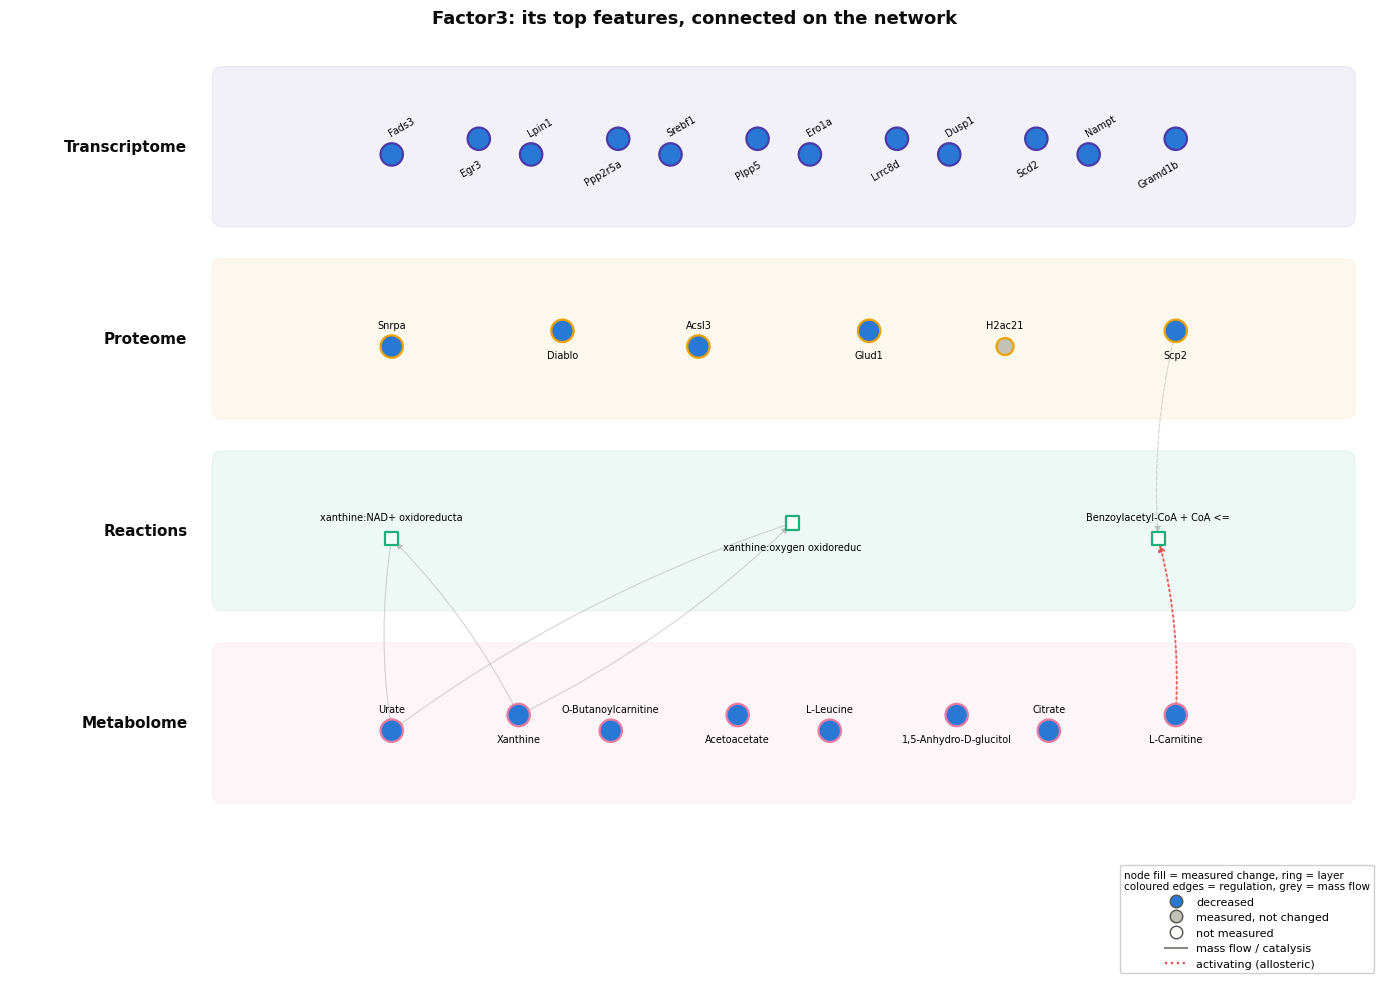

In [28]:
from transnet.visualization import plot_factor_network

plot_factor_network(graph, factorisation.loadings_, leading, id_maps=id_map, top_n=12)
plt.show()

## Timing: three metabolic states

The paper reports three states, uninduced (0 h), active lipolysis (4 h) and
sustained induction (24 h), with the metabolome moving first. Clustering
the metabolite trajectories over all seven timepoints asks the same question
of the same data.

In [29]:
metabolome = omics["Metabolome"]
labels = [str(c).split("_")[0] for c in metabolome.columns]
# one x-value per group, in the order the groups appear
hours = [BROWN_ADIPOCYTE_HOURS[label] for label in dict.fromkeys(labels)]

omnibus = compute_timecourse_statistics(metabolome, groups=labels, method="anova",
                                        trend_test=True, continuous_x=hours)
print(f"{(omnibus['fdr'] <= 0.05).sum()} of {len(omnibus)} metabolites change across "
      f"the time course (one-way ANOVA over all seven points, BH-corrected); "
      f"{(omnibus['trend_pval'] <= 0.05).sum()} follow a monotone trend")
omnibus.sort_values("fdr").head(8)

88 of 171 metabolites change across the time course (one-way ANOVA over all seven points, BH-corrected); 70 follow a monotone trend


,feature,stat,pval,slope,r_value,trend_pval,fdr,trend_fdr
0,3-hydroxyglutaric acid,127.568496,2.708314e-22,-0.064557,-0.634795,6.329188e-06,3.295747e-20,6.012728e-05
1,uric acid,124.891639,3.854675e-22,-0.072839,-0.670758,1.170400e-06,3.295747e-20,1.619317e-05
2,5-methoxy-5-oxopentanoic acid,99.783660,1.576792e-20,-0.088686,-0.809388,8.677360e-11,8.987712e-19,3.709571e-09
3,threonic acid,81.886775,3.972447e-19,-0.057008,-0.095634,5.468681e-01,1.698221e-17,7.016279e-01
4,l-leucine,62.015856,3.419951e-17,-0.072401,-0.674479,9.699841e-07,1.169623e-15,1.507884e-05
5,isovalerylcarnitine,53.578507,3.406339e-16,-0.015574,-0.318060,4.010133e-02,9.708067e-15,1.075414e-01
6,o-butanoylcarnitine,52.069406,5.315094e-16,-0.050099,-0.740996,2.006072e-08,1.298402e-14,4.900548e-07
7,glucose-1-phosphate,50.162925,9.480761e-16,-0.039386,-0.770116,2.483144e-09,2.026513e-14,8.492354e-08


In [30]:
clusters, profiles = cluster_temporal_trajectories(metabolome, timepoints=labels,
                                                   n_clusters=3)
clusters.value_counts().rename("metabolites").to_frame()

,metabolites
cluster,
0,81
2,49
1,41


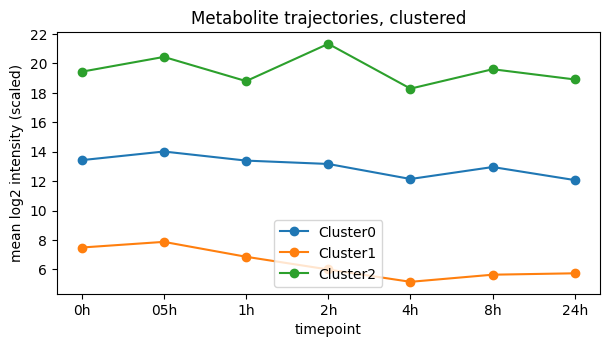

In [31]:
ordered = [t for t in BROWN_ADIPOCYTE_HOURS if t in profiles.columns]
profiles[ordered].T.plot(marker="o", figsize=(7, 3.4))
plt.xlabel("timepoint")
plt.ylabel("mean log2 intensity (scaled)")
plt.title("Metabolite trajectories, clustered")
plt.show()

## The wiring itself: motifs, bottlenecks, and a null

Everything above reads data *through* the network. These three read the
network, and are the analyses a molecule list cannot approximate at all.

In [32]:
from transnet import (
    convergence_significance,
    regulatory_motifs,
    structural_vulnerability,
)

motifs = regulatory_motifs(graph, responsive_only=True)
print(motifs["counts"])
motifs["motifs"].head(12)[["motif", "reaction_name", "metabolite_name", "enzyme",
                           "sign_product"]]

{'feed_forward': 228, 'allosteric_feedback': 5, 'product_inhibition': 1}


,motif,reaction_name,metabolite_name,enzyme,sign_product
0,allosteric_feedback,L-cystathionine L-homocysteine-lyase (de,L-Methionine,"tRNA(Phe)-N1-methylguanine,pyruvate acet",-1
1,product_inhibition,trimethylaminoacetate:L-homosysteine S-m,L-Methionine,None,-1
2,allosteric_feedback,S-alkyl-L-cysteine alkylthiol-lyase (dea,L-Methionine,"tRNA(Phe)-N1-methylguanine,pyruvate acet",-1
3,allosteric_feedback,L-cysteine-S-conjugate aryl-thiol-lyase,L-Methionine,"tRNA(Phe)-N1-methylguanine,pyruvate acet",-1
4,allosteric_feedback,selenocystathionine L-homocysteine-lyase,L-Methionine,"tRNA(Phe)-N1-methylguanine,pyruvate acet",-1
5,allosteric_feedback,L-cysteine-S-conjugate thiol-lyase (deam,L-Methionine,"tRNA(Phe)-N1-methylguanine,pyruvate acet",-1
6,feed_forward,NADH:ubiquinone oxidoreductase,None,Ogdh,0
7,feed_forward,NADH:ubiquinone oxidoreductase,None,Hcfc1,0
8,feed_forward,4-hydroxyphenylacetate:CoA ligase (AMP-f,None,Hcfc1,0
9,feed_forward,3-Hydroxypropionyl-CoA + Orthophosphate,None,Hcfc1,0


Each product-inhibition row is a reaction whose own product holds it back,
with both the enzyme and the metabolite measured here, which is the mechanism behind
a reaction that slows while its enzyme rises.

In [33]:
vulnerability = structural_vulnerability(responsive)
vulnerability.head(10)

,node,name,layer,fragments,largest_loss,cross_layer_degree
0,Q9JIK5,Ddx21,Proteome,668,0.111166,1
1,Q9CU62,Smc1a,Proteome,131,0.022333,1
2,Q9Z103,Adnp,Proteome,48,0.007775,1
3,Q64511,Top2b,Proteome,23,0.003805,1
4,E9Q1P8,Irf2bp2,Proteome,20,0.003143,1
5,Q61191,Hcfc1,Proteome,11,0.001820,1
6,12834,Col6a2,Transcriptome,2,0.000993,1
7,O08528,Hk2,Proteome,3,0.000827,1
8,Q02788,Col6a2,Proteome,2,0.000827,1
9,11636,Ak1,Transcriptome,2,0.000662,1


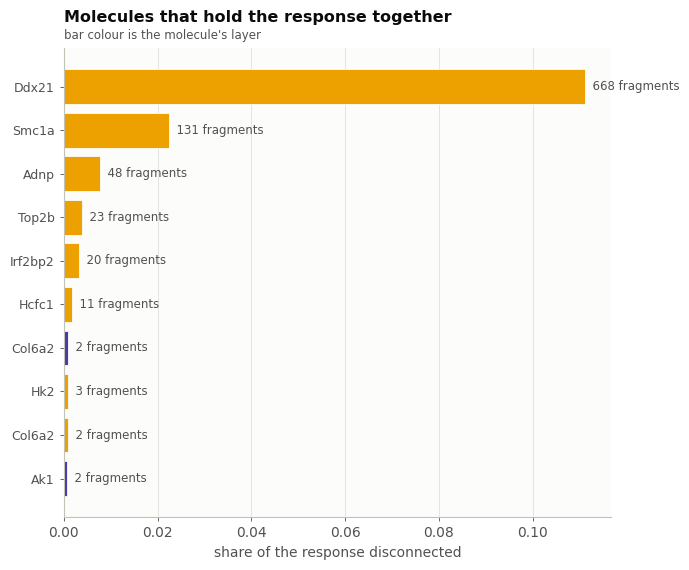

In [34]:
from transnet.visualization import (
    plot_convergence_null,
    plot_regulatory_motifs,
    plot_structural_vulnerability,
)

vulnerability_figure = plot_structural_vulnerability(vulnerability)
plt.show()

Those are the molecules the response runs through: remove one and the rest
of the response is no longer connected to what it regulates.

In [35]:
convergence = convergence_significance(graph, n_randomisations=200)
print(f"{convergence['observed']:,} reactions have both a changed enzyme and a changed "
      f"metabolite; shuffling which molecules changed gives "
      f"{convergence['null_mean']:.0f} (z = {convergence['z']:+.1f}, "
      f"p = {convergence['p_value']:.3g})")

170 reactions have both a changed enzyme and a changed metabolite; shuffling which molecules changed gives 19 (z = +4.4, p = 0.0149)


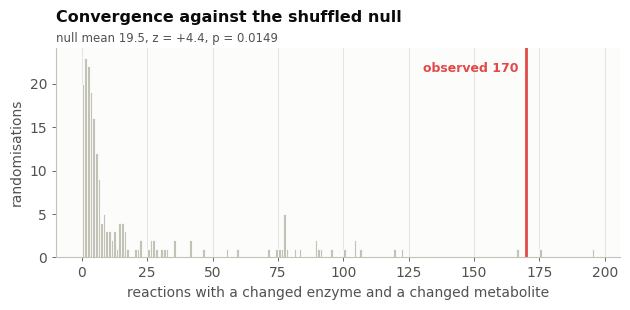

In [36]:
convergence_figure = plot_convergence_null(convergence)
plt.show()

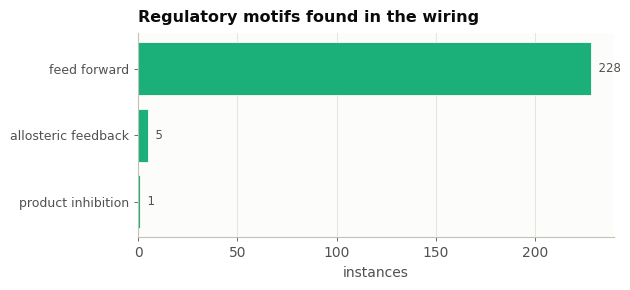

In [37]:
motif_figure = plot_regulatory_motifs(motifs)
plt.show()

## Compared with the published analysis

| The paper concluded | Here |
|---|---|
| Three states: uninduced (0 h), active lipolysis (4 h), sustained (24 h) | the metabolite trajectories cluster into that many distinct shapes, above |
| The metabolome moves before the transcriptome and proteome | the responsive metabolites are already significant at 4 h while the protein changes concentrate at 24 h |
| Lipid-droplet genes (*Sqle*, *Fdft1*) fall as transcripts while their proteins rise | the same genes land in the `discordant` category of transcript-protein concordance, without being looked for |
| Upper glycolysis (*Pfkl*, *Pfkp*) down, lower glycolysis (*Pklr*) up | checked directly below |

The paper reached its trans-omic observations, the Rock2/protamine link and
the glycolytic split, by reading a network by hand. The point of the table
above is that the same statements fall out of the catalogue as ordinary
output, with the axis attribution and the threshold-free transcript-protein
test attached.

In [38]:
GLYCOLYSIS = ["Pfkl", "Pfkp", "Pfkm", "Pklr", "Pkm", "Hk1", "Hk2", "Gpi1", "Eno1"]
named[named["symbol"].isin(GLYCOLYSIS)][
    [c for c in ("symbol", "gene_log2fc", "protein_log2fc", "category") if c in named.columns]
]

,symbol,gene_log2fc,protein_log2fc,category
163,Hk2,-1.297360,-0.362407,concordant
488,Pkm,-1.847009,-0.135521,transcript_only
777,Pfkl,-1.321090,0.092895,transcript_only


## Figures

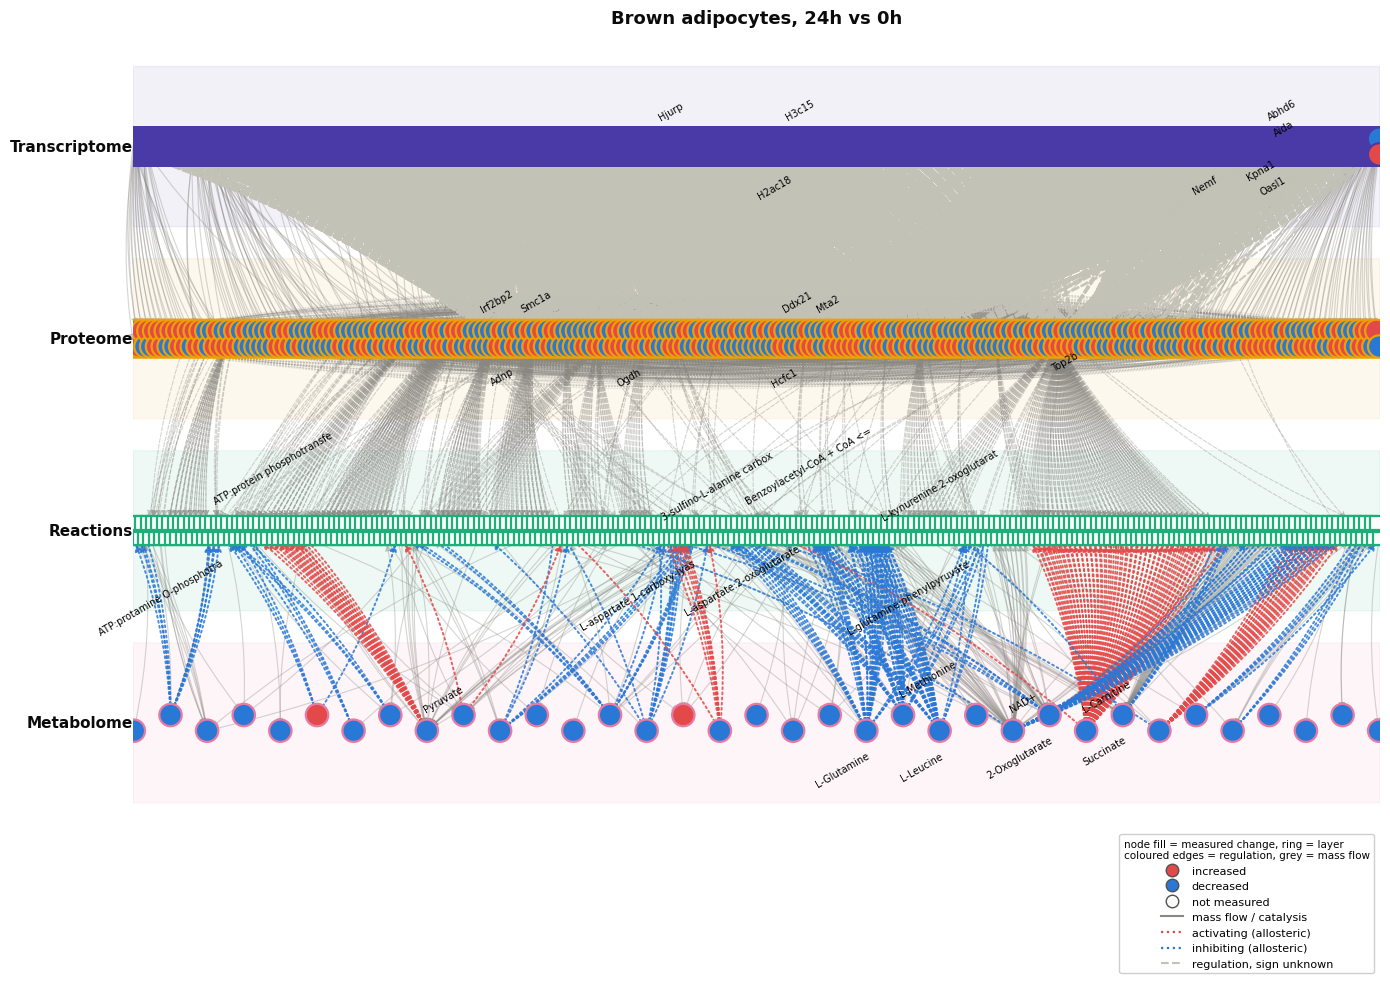

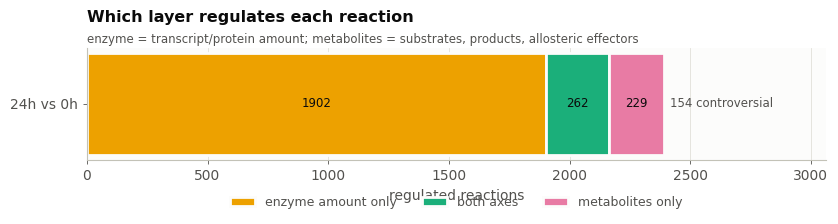

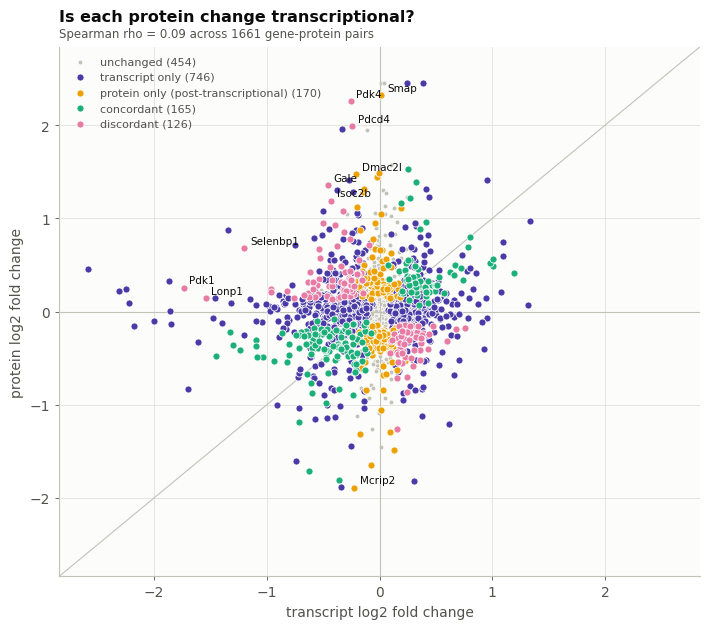

figures and tables in /Users/krv114/Documents/GitHub/transnet/data/brown_adipocyte_results


In [39]:
from transnet.visualization import (
    plot_expression_concordance,
    plot_axis_composition,
    plot_transomic_network,
)

composition = pd.DataFrame([{
    "contrast": f"{TREATMENT} vs {CONTROL}",
    "enzyme_axis_only": len(enzyme_only),
    "metabolite_axis_only": len(metabolite_only),
    "both_axes": len(both),
    "controversial": len(controversial),
}])

for figure, name in [
    (plot_transomic_network(responsive, title=f"Brown adipocytes, {TREATMENT} vs {CONTROL}"),
     "network"),
    (plot_axis_composition(composition), "regulation_axes"),
    (plot_expression_concordance(concordance), "concordance"),
    (convergence_figure, "convergence_null"),
    (vulnerability_figure, "structural_vulnerability"),
    (motif_figure, "regulatory_motifs"),
    (paths_figure, "regulatory_paths"),
]:
    figure.savefig(OUT / f"{name}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"figures and tables in {OUT}")